## **Introdução**

Este notebook tem como objetivo aplicar os dados de calibração de temperatura aos resultados de difração, permitindo uma análise mais precisa em relação ao comportamento real da amostra durante o experimento. O foco principal é substituir a temperatura obtida pelo cryojet pela temperatura real medida pelo termopar.

### **Importando as bibliotecas necessárias**


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns
from glob import glob
import numpy as np
import funcoes

# Configuração de fonte para o plot dos dados
plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm", "font.size": 12})


## **Importando os dados**


Nesse projeto serão utilizados dois conjuntos de dados: 

- **``PROC``**: Essa pasta contém os dados de difração de raio X para cada um dos crioprotetores, com os dados crus já processados. Dentro das pastas dos crioprotetores nós temos a seguinte estrutura para os arquivos _.csv_ do dados:

    - **nome do arquivo**: no nome do arquivo há as informações: tipo de crioprotetor utilizado, a temperatura em que houve a medição (é utilizado o valor de temperatura durante o primeiro instante dos 23 segundos de medição) e o número na sequência de aquisição. 
 
    - **2theta (degree)**: é o ângulo de difração medido na difração de raio X.

    - **Intensity**: é radiação do espalhamento medida em uma área.

- **``Calibração``**: A tabela de calibração contém os valores de temperatura obtidos por um termopar, de forma que esses valores representam a temperatura da amostra durante as medições, ao mesmo tempo em que estavam submetidas ao cryojet. Dessa meneira, é possível notar a diferença entre as temperaturas medidas pelo cryojet e pelo termopar. Estrutura:

    - **cryojet_current_temp[K]**: é a temperatura medida pelo cryojet, em Kelvin.

    - **Setpoint[K]**: é a temperatura alvo estabelecida para o cryojet.

    - **T1[K]**: é a temperatura medida pelo termopar.

    - **Time[h-m-s]**: é o registro do instante da medição em hora-minuto-segundo.

**``OBS``**: Os dados de calibração vieram a princípio em um formato de pdf e foram extraídos e passados para _.csv_. (``extracao_dados_calib_temp.ipynb``)

Como o tempo decorrido desde o início das medições pode ser um dado útil para o alinhamento dos datasets, será utilizado o período de aquisição que havia nos dados crus (*acquire_period*) para encontrar o tempo decorrido desde a primeira medição.

In [25]:
periodo_aqu = 23.200001

### **PROC**


Estão sendo utilizados os arquivos do crioprotetor vs55 como exemplo para o desenvolvimento do código. Primeiramente foram listados todos os arquivos *.csv* da pasta para serem parte do conjunto de dados ``df_proc``, juntamente com as informações da medição: 

- [``nome``]: o nome do arquivo;

- [``temperatura[K]``]: o valor de temperatura (medido pelo cryojet); 

- [``step``]: o número na sequência; 
 
- [``tempo_decorrido[s]``]: o tempo decorrido. 
 
Como existem dados em que os valores de temperatura eram alterados durante a medição, os arquivos que representam esse tipo de medição receberam o nome com *"RAMP"* nele. (Isso impacta na extração de informações no nome do arquivo, havendo mudanças nos índices)

In [26]:
df_proc = funcoes.extrair_dados_proc("../dados/proc/main_folder_vs55/merge_files", periodo_aqu)

display(df_proc[["nome", "temperatura[K]", "step", "tempo_decorrido[s]"]].head())
print(f"\nLinhas: {df_proc.shape[0]}, Colunas: {df_proc.shape[1]}")

,nome,temperatura[K],step,tempo_decorrido[s]
0,vs55_RAMP_296Kelvin_128_MERGE,296.0,128,0.000000
1,vs55_RAMP_285Kelvin_130_MERGE,285.0,130,23.200001
2,vs55_RAMP_279Kelvin_132_MERGE,279.0,132,46.400002
3,vs55_RAMP_272Kelvin_134_MERGE,272.0,134,69.600003
4,vs55_RAMP_263Kelvin_136_MERGE,263.0,136,92.800004



Linhas: 65, Colunas: 5


#### **Corrigindo Anomalias**

In [27]:
target_2theta_anom = 16
tol_2theta_anom = 1

idx_range_anom = 15

df_proc = funcoes.corrigir_anomalia(target_2theta_anom, tol_2theta_anom, idx_range_anom, df_proc)

### **Tabela de Calibração**

Assim como no ``df_proc``, nessa tabela de calibração, ``df_calib``, foi adicionada a coluna de tempo decorrido, de forma que foi necessário converter os horários, que estavam no formato de [hora-minuto-segundo] para segundos. 

In [28]:
df_calib = funcoes.extrair_tabela_calib("../dados/extracted/tabela_extraida_calib_temp.csv")

display(df_calib.head())
print(f"Linhas: {df_calib.shape[0]}, Colunas: {df_calib.shape[1]}")

,cryojet_current_temp[K],Setpoint[K],T1[K],Time[h-m-s],tempo_decorrido[s]
0,296.44,296.44,299.350001,11-30-14,0.0
1,296.16,296.20,299.449999,11-30-24,10.0
2,295.82,295.85,299.449999,11-30-34,20.0
3,295.69,295.69,299.550000,11-30-44,30.0
4,295.56,80.00,299.350001,11-30-54,40.0


Linhas: 608, Colunas: 5


Para realizar o processo de alinhamento dos dados baseando-se na equivalência das temperaturas do cryojet em ambas as medições, é necessário dividir os dados entre as fases de resfriamento e de aquecimento. Visto que os dados de calibração contém ambas as curvas, um valor de temperatura de referência no ``df_proc`` poderia encontrar dois pontos de temperatura próxima na claibração. Sem a distinção, há o risco de associar dois processos de evolução temporal e térmica distintos para a amostra, considerando que para a que equivalência seja válida os dados comparados devem pertencer à mesma fase do ciclo térmico.

Para encontrar o valor do ponto de inflexão da curva foi utilizado o valor mínimo de temperatura, que foi uma boa aproximação para os dados do crioprotetor utilizado. Esse processo não é muito robusto e exige uma análise acerca dos dados utilizados.

In [29]:
df_calib_resf, df_calib_aquec, idx_calib, min_temp_calib = \
    funcoes.separar_curvas(df_calib, "cryojet_current_temp[K]")

df_proc_resf, df_proc_aquec, idx_proc, min_temp_proc = \
    funcoes.separar_curvas(df_proc, "temperatura[K]")

print("--- Dataframes de Calibração ---")
print(f"Resfriamento: linhas = {df_calib_resf.shape[0]}; colunas = {df_calib_resf.shape[1]}")
print(f"Aquecimento: linhas = {df_calib_aquec.shape[0]}; colunas = {df_calib_aquec.shape[1]}")
print(f"Min. Temp = {min_temp_calib}")

print("\n--- Dataframes PROC ---")
print(f"Resfriamento: linhas = {df_proc_resf.shape[0]}; colunas = {df_proc_resf.shape[1]}")
print(f"Aquecimento: linhas = {df_proc_aquec.shape[0]}; colunas = {df_proc_aquec.shape[1]}")
print(f"Min. Temp = {min_temp_proc}")

--- Dataframes de Calibração ---
Resfriamento: linhas = 159; colunas = 5
Aquecimento: linhas = 449; colunas = 5
Min. Temp = 79.96000000000001

--- Dataframes PROC ---
Resfriamento: linhas = 27; colunas = 5
Aquecimento: linhas = 38; colunas = 5
Min. Temp = 80.0


## **Alinhamento dos Dados**


Primeiramente, foi pensado em definir um ponto inicial de alinhamento,  visto que as medições de difração e de calibração podem apresentar instantes iniciais distintos. Logo, para sincronizá-las, pareou-se a temperatura inicial da medição de difração com a temperatura mais próxima da calibração. [Processo realizado na célula abaixo]

Exemplo: Se $T_{calib} = [296.44, 296.16, 295.82, \dots]$ e $T_{proc\_inicial} = 296$ K, determina-se $T_{calib\_inicial} = 296.16$ K.



Estabelecido o ponto inicial, a primeira tentativa de alinhamento utilizou o tempo decorrido como critério de equivalência. Dessa forma, cada ponto de difração foi associado à medição do termopar mais próxima temporalmente. Além disso, como maneira de verificar o tamanho do erro de uma aproximação, calculou-se a diferença entre as temperaturas do cryojet nos dados processados e nos de calibração após o alinhamento. 

No entanto, essa abordagem não se mostrou muito boa, uma vez que, embora a diferença inicial fosse pequena, o erro divergiu significativamente ao longo do experimento, atingindo diferenças de mais 80 K. Esse comportamento indica que, provavelmente, que as taxas de aquecimento e resfriamento variam entre as medições, causando uma dessincronização entre a temperatura da amostra e da calibração.

Como alternativa, foi utilizada a temperatura do cryojet como base para o alinhamento. Para cada ponto de referência nos dados processados, buscou-se o valor de temperatura mais próximo nos dados de calibração. Também, como uma forma de ver a evolução do erro, foi feita diferença entre os instantes de tempo de ambos os conjuntos de dados.

Fazendo agora esse processo de alinhamento pela temperatura do cryojet.

Se for do interesse fazer alinhamento com base no tempo decorrido é necessário remover os condicionais e encontrar o índice por: *``idx_prox = np.abs(df_calib["tempo_decorrido[s]"] - t_proc).idxmin()``*

In [30]:
df_temp_corr, stats = funcoes.alinhar_por_temperatura(df_proc, df_calib)

display(df_temp_corr.head())
print(f"Shape: {df_temp_corr.shape}")

print(f"Média e desvio padrão da diferença de temperatura do cryojet: {stats['media_diff_temp']:.6f} ± {stats['std_diff_temp']:.6f}")
print(f"Média e desvio padrão da diferença de tempo: {stats['media_diff_t']:.6f} ± {stats['std_diff_t']:.6f}")

,t_decorrido_proc,t_decorrido_calib,temp_t1,temp_cryojet_calib,temp_cryojet_proc,diff_temp_cryojet,diff_t
0,0.000000,0.0,299.449999,296.16,296.0,-0.16,0.000000
1,23.200001,51.0,291.250000,286.03,285.0,-1.03,-27.799999
2,46.400002,71.0,286.850000,280.13,279.0,-1.13,-24.599998
3,69.600003,101.0,280.350000,271.78,272.0,0.22,-31.399997
4,92.800004,131.0,274.250000,262.98,263.0,0.02,-38.199996


Shape: (65, 7)
Média e desvio padrão da diferença de temperatura do cryojet: 0.024154 ± 0.379947
Média e desvio padrão da diferença de tempo: -1243.076891 ± 838.286855


#### **Aplicando a temperatura de calibração**

Substituindo os valores de temperatura do cryojet da tabela dos dados processados pelos valores de temperatura do termopar que foram alinhados.

In [31]:
df_proc_final = df_proc.copy()
df_proc_final["temperatura[K]"] = df_temp_corr["temp_t1"].values

display(df_proc_final.head())

,nome,temperatura[K],step,dados,tempo_decorrido[s]
0,vs55_RAMP_296Kelvin_128_MERGE,299.449999,128,2theta (degree) Intensity (a.u.) 0 ...,0.000000
1,vs55_RAMP_285Kelvin_130_MERGE,291.250000,130,2theta (degree) Intensity (a.u.) 0 ...,23.200001
2,vs55_RAMP_279Kelvin_132_MERGE,286.850000,132,2theta (degree) Intensity (a.u.) 0 ...,46.400002
3,vs55_RAMP_272Kelvin_134_MERGE,280.350000,134,2theta (degree) Intensity (a.u.) 0 ...,69.600003
4,vs55_RAMP_263Kelvin_136_MERGE,274.250000,136,2theta (degree) Intensity (a.u.) 0 ...,92.800004


## **Plotando os dados**

Agora, com as temperaturas devidamente calibradas e os dados alinhados, passamos para a visualização dos difratogramas. 

O objetivo é observar a evolução dos perfis de difração à medida que a temperatura da amostra varia, permitindo a identificação de mudanças estruturais, visto que quando há a formação de cristais são formados picos de difração. 

Para possibilitar a comparação de vários perfis em um único gráfico, foi aplicado um *offset* no eixo $y$, permitindo observar mais claramente o surgimento ou desaparecimento de picos ao longo do ciclo térmico. Foi também aplicado um mapa de cores que representa a temperatura, para deixar a análise mais "intuitiva". Além disso, os dados foram plotados de forma sequencial, em que a curva mais baixa representa a primeira aquisição e a última curva a última aquisição.

É válido dizer que os valores do eixo $y$ serão omitidos visto que com a adição do offset eles não se tornam mais tão representativos, embora isso não seja um problema para a análise em questão, que busca visualizar a formação de picos. 


In [32]:
funcoes.plot_difracao(df_proc_final, 'VS55')

No gráfico é possível observar que por volta de 200 a 235 graus provavelmente houve a cristalização, em razão da formação de picos de difração

### **Plotando uma matriz de correlação**


Definidos os pontos em que provavlemente houve uma crstalização e 

A contrução da matriz de correlação, foi feita como uma forma de investigar as relações estatísticas entre as intensidades em diferentes ângulos de difração sob diferentes condições térmicas. Isso, a fim de verificar se as variações de intensidade em determinados ângulos acompanham as flutuações de outros, o que pode ajudar a indicar que houve um novo padrão de difração. 

O processo de cálculo e visualização necessitou dos seguintes procedimentos:

- Filtragem: utilizou-se parâmetros de busca (``target_temp`` e ``target_2theta``) para isolar uma região de interesse nos dados.

- Cálculo: a matriz é gerada utilizando o método de Pearson (``method="pearson"``), que quantifica a força e a direção da relação linear entre os pares de intensidades nos ângulos selecionados.

- Visualização: o gráfico foi feito com a função ``sns.heatmap``.

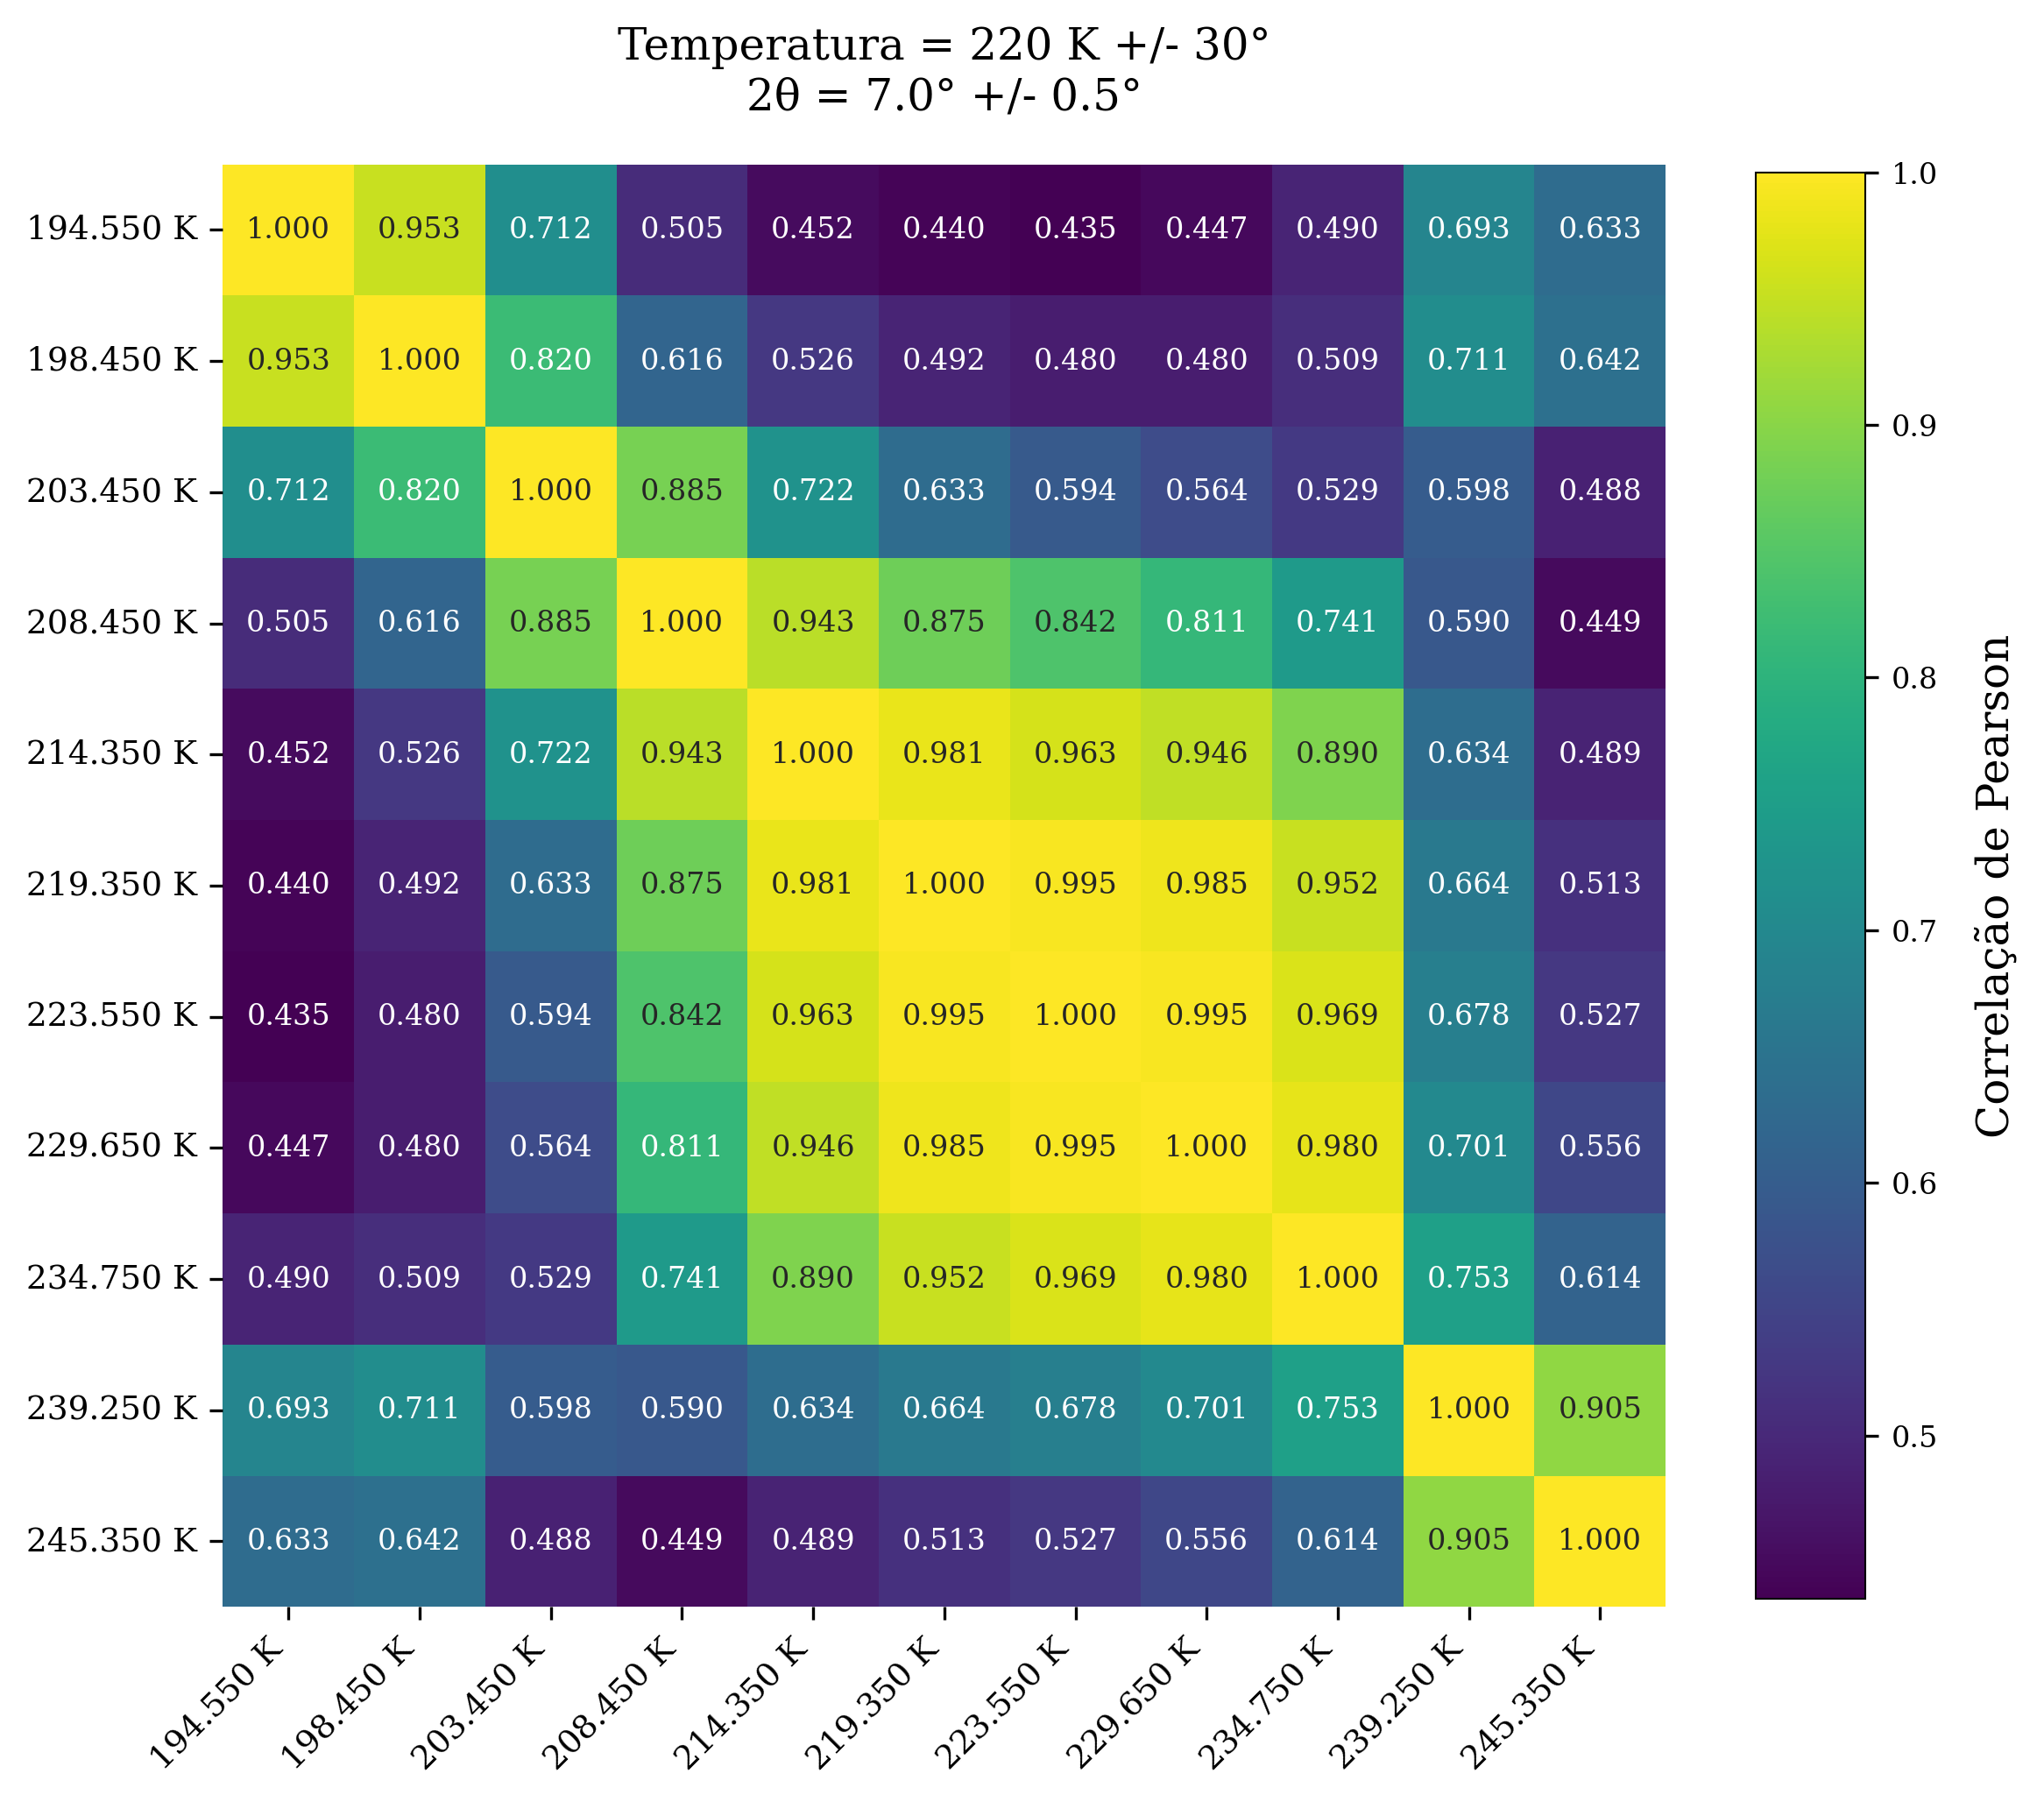

In [33]:
target_temp = 220
tol_temp = 30

target_2theta = 7.0
tol_2theta = 0.5

dados_filtrados = {}

for i, linha in df_proc_final.iterrows():
    nome = linha["nome"]
    temp = linha["temperatura[K]"]
    step =linha["step"]
    df = linha["dados"]

    if (target_temp - tol_temp) <= temp <= (target_temp + tol_temp) and step >= 200:
        df_filtro = df[
            (df["2theta (degree)"] >= target_2theta - tol_2theta)
            & (df["2theta (degree)"] <= target_2theta + tol_2theta)
        ]

        dados_filtrados[f"{temp:.3f} K"] = df_filtro["Intensity (a.u.)"].values


df_matrix = pd.DataFrame(dados_filtrados)
corr_matrix = df_matrix.corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

heatmap = sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap="viridis",
    annot=True,
    fmt=".3f",
    annot_kws={"size": 8},
    square=True,
    cbar_kws={
        "shrink": 0.92,
        "aspect": 13
    }
)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.5)
cbar.set_label("Correlação de Pearson", labelpad=10)

ax.set_title(
    f"Temperatura = {target_temp} K +/- {tol_temp}°\n2θ = {target_2theta}° +/- {tol_2theta}°",
    pad=15,
    fontsize=12,
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.show()